In [3]:
import numpy as np

class1_sample = np.random.randn(20, 3)
class2_sample = np.random.randn(20, 3) + 2
df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)
df = df.sample(n=40, random_state=42).reset_index(drop=True)

df



,feature1,feature2,feature3,target
0,0.668550,0.577391,-1.062523,1
1,0.782193,0.032433,-0.697952,1
2,-1.266884,0.891250,-2.440087,1
3,0.925692,1.389458,3.122787,0
4,0.757174,0.725885,1.009042,1
5,-1.325426,-0.493928,-1.903986,1
6,2.246491,3.680610,1.304555,0
7,0.765403,-0.222560,1.452155,0
8,1.056737,0.433586,1.414792,0
9,0.540351,-1.264774,-0.440251,1


In [4]:
df.head()

,feature1,feature2,feature3,target
0,0.668550,0.577391,-1.062523,1
1,0.782193,0.032433,-0.697952,1
2,-1.266884,0.891250,-2.440087,1
3,0.925692,1.389458,3.122787,0
4,0.757174,0.725885,1.009042,1


In [5]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [6]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [7]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.60435756 0.55778788]
 [0.60435756 1.02564103 0.47866528]
 [0.55778788 0.47866528 1.02564103]]


In [8]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [9]:
eigen_values

array([2.12112554, 0.40420281, 0.55159473])

In [10]:

eigen_vectors

array([[ 0.60026315,  0.78782091, -0.13792159],
       [ 0.57435521, -0.54461135, -0.61115838],
       [ 0.55659701, -0.28763987,  0.77939917]])

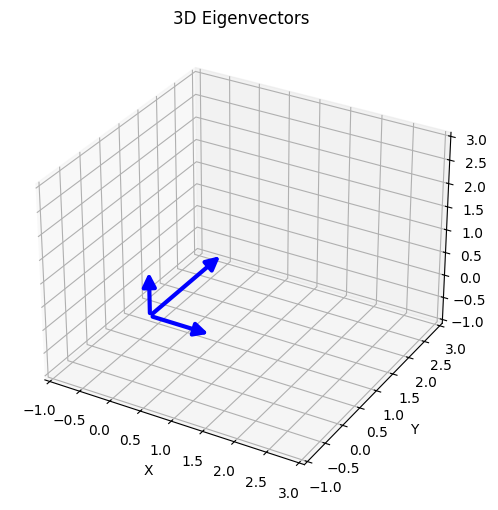

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# Modern Arrow3D class (fixed for new Matplotlib)
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        # Use ax.get_proj() instead of renderer.M
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        # z-order for proper layering
        _, _, zs = self._verts3d
        return np.min(zs)

# -----------------------------
# Example 3D eigenvector plot
# -----------------------------
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Center of the eigenvectors (mean of data is better, here 0 for example)
mx, my, mz = 0, 0, 0

# Example eigenvectors (replace with your real eigenvectors)
eigen_vectors = np.array([[1, 0, 0],
                          [0, 2, 0],
                          [0, 0, 1]])

# Draw arrows for each eigenvector
for v in eigen_vectors.T:
    arrow = Arrow3D(
        [mx, mx + v[0]],
        [my, my + v[1]],
        [mz, mz + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color='blue'
    )
    ax.add_artist(arrow)

# Axes limits and labels
ax.set_xlim([-1, 3])
ax.set_ylim([-1, 3])
ax.set_zlim([-1, 3])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("3D Eigenvectors")

plt.show()


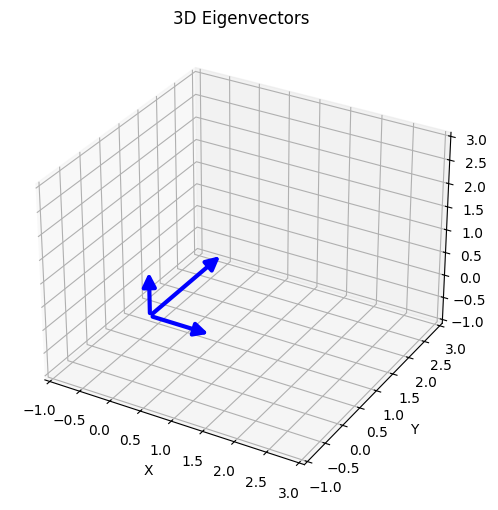

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# Modern Arrow3D class (fixed for new Matplotlib)
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        # Use ax.get_proj() instead of renderer.M
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        # z-order for proper layering
        _, _, zs = self._verts3d
        return np.min(zs)

# -----------------------------
# Example 3D eigenvector plot
# -----------------------------
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Center of the eigenvectors (mean of data is better, here 0 for example)
mx, my, mz = 0, 0, 0

# Example eigenvectors (replace with your real eigenvectors)
eigen_vectors = np.array([[1, 0, 0],
                          [0, 2, 0],
                          [0, 0, 1]])

# Draw arrows for each eigenvector
for v in eigen_vectors.T:
    arrow = Arrow3D(
        [mx, mx + v[0]],
        [my, my + v[1]],
        [mz, mz + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color='blue'
    )
    ax.add_artist(arrow)

# Axes limits and labels
ax.set_xlim([-1, 3])
ax.set_ylim([-1, 3])
ax.set_zlim([-1, 3])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("3D Eigenvectors")

plt.show()


In [21]:
pc = eigen_vectors[0:2]
pc

array([[1, 0, 0],
       [0, 2, 0]])

In [22]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-0.136704,-0.510897,1
1,-0.064653,-1.273475,1
2,-1.363789,-0.071704,1
3,0.026326,0.625454,0
4,-0.080515,-0.303105,1


In [ ]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()